# Developpement des algorithmes ICA

Ce notebook est un brouillon

In [ ]:
import sys
sys.path.insert(0, '/home/abdoulayediallo/ICA/ICA-Stochastic-Project')

import numpy as np
import matplotlib.pyplot as plt
from src.algorithms import amari_index, fastica_unmixing_matrix, sgd_ica, adam_ica
from src.utils import center_whiten, generate_synthetic_data

# Reproductibilite
rng = np.random.default_rng(42)


In [26]:
# Génération de données synthétiques via generate_synthetic_data
D = 3
N = 5000
X, S, A = generate_synthetic_data(D=D, N=N, seed=42)


## Pretraitement (centrage + whitening)

On centre les donnees puis on applique un whitening PCA afin d'avoir une covariance proche de l'identite.
Ce pretraitement stabilise les mises a jour ICA.

In [35]:
# center_whiten est maintenant importée depuis src.utils
# On peut tester directement
Xw, mu, W_white = center_whiten(X)


In [36]:
# Test rapide du pretraitement sur un melange synthetique

X = A @ S
Xw, mu, W_white = center_whiten(X)

cov_w = (Xw @ Xw.T) / N
err_cov = np.max(np.abs(cov_w - np.eye(D)))

print("Covariance blanchie (approx):")
print(np.round(cov_w, 3))
print(f"ecart max a I: {err_cov:.3e}")

assert err_cov < 5e-2, "Whitening insuffisant: covariance trop eloignee de I"
print("Pretraitement valide.")

Covariance blanchie (approx):
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]
ecart max a I: 1.574e-07
Pretraitement valide.


## FastICA

On appelle directement la fonction definie dans src.algorithms.
On evalue la separation avec l'indice d'Amari sur $C = \hat V A$.

In [38]:
# FastICA via fonction du projet (src.algorithms)
V_hat, B_hat, Xw_fast, mu_fast, W_white_fast = fastica_unmixing_matrix(
    X,
    whitening_fn=center_whiten,
    n_components=D,
    max_iter=1000,
    tol=1e-6,
    seed=42,
)


NameError: name 'fastica_unmixing_matrix' is not defined

In [ ]:
C_fastica = V_hat @ A
amari_fastica = amari_index(C_fastica)
print(f"Amari FastICA (fonction projet): {amari_fastica:.4f}")
print("Matrice C = V_hat A (arrondie):")
print(np.round(C_fastica, 3))

Amari FastICA sklearn: 0.0147
Matrice C = V_hat A (arrondie):
[[ 0.01   0.044  0.604]
 [-0.002  1.737 -0.   ]
 [ 0.707 -0.019  0.002]]


## SGD-ICA

In [7]:
# sgd_ica est maintenant importée depuis src.algorithms
# On teste directement avec les données prétraitées
Xw_test, mu_test, W_white_test = center_whiten(X)


## Adam-ICA

In [20]:
# adam_ica est maintenant importée depuis src.algorithms
# Les deux algorithmes stochastiques sont prêts à être utilisés
print("SGD-ICA et Adam-ICA sont importées depuis src.algorithms")


SGD-ICA et Adam-ICA sont importées depuis src.algorithms


In [29]:
# Test SGD-ICA et Adam-ICA (Infomax)
Xw, mu, W_white = center_whiten(X)

# Hyperparametres stables identifies pour la version Infomax
W_sgd, hist_sgd = sgd_ica(Xw, n_iter=1000, lr=0.01, batch_size=32, seed=42)
W_adam, hist_adam = adam_ica(Xw, n_iter=1000, lr=0.0005, batch_size=32, seed=42)

# Compute unmixing matrix: V = W @ W_white for whitened data
V_sgd = W_sgd @ W_white
V_adam = W_adam @ W_white

# Evaluate
C_sgd = V_sgd @ A
C_adam = V_adam @ A

amari_sgd = amari_index(C_sgd)
amari_adam = amari_index(C_adam)

print(f"Amari SGD-ICA (Infomax): {amari_sgd:.4f}")
print(f"Amari Adam-ICA (Infomax): {amari_adam:.4f}")
print(f"Amari FastICA: {amari_fastica:.4f}")

Amari SGD-ICA (Infomax): 0.1324
Amari Adam-ICA (Infomax): 0.2553
Amari FastICA: 0.0147


In [32]:
# Test avec différents learning rates
print("Testing with different learning rates...\n")

Xw_lr, mu_lr, W_white_lr = center_whiten(X)

# Test SGD avec learning rates différents
learning_rates_sgd = [0.001, 0.005, 0.01, 0.05]
print("SGD-ICA avec différents learning rates (n_iter=500):")
for lr_test in learning_rates_sgd:
    W_sgd_lr, _ = sgd_ica(Xw_lr, n_iter=500, lr=lr_test, batch_size=32, seed=42)
    V_sgd_lr = W_sgd_lr @ W_white_lr
    C_sgd_lr = V_sgd_lr @ A
    amari_sgd_lr = amari_index(C_sgd_lr)
    print(f"  lr={lr_test:.4f}: Amari = {amari_sgd_lr:.4f}")

# Test Adam avec learning rates différents
learning_rates_adam = [0.0001, 0.0005, 0.001, 0.005]
print("\nAdam-ICA avec différents learning rates (n_iter=500):")
for lr_test in learning_rates_adam:
    W_adam_lr, _ = adam_ica(Xw_lr, n_iter=500, lr=lr_test, batch_size=32, seed=42)
    V_adam_lr = W_adam_lr @ W_white_lr
    C_adam_lr = V_adam_lr @ A
    amari_adam_lr = amari_index(C_adam_lr)
    print(f"  lr={lr_test:.5f}: Amari = {amari_adam_lr:.4f}")

print(f"\nFastICA pour comparaison: Amari = {amari_fastica:.4f}")


Testing with different learning rates...

SGD-ICA avec différents learning rates (n_iter=500):
  lr=0.0010: Amari = 0.3781
  lr=0.0050: Amari = 0.2948
  lr=0.0100: Amari = 0.2079
  lr=0.0500: Amari = 0.3641

Adam-ICA avec différents learning rates (n_iter=500):
  lr=0.00010: Amari = 0.3797
  lr=0.00050: Amari = 0.2963
  lr=0.00100: Amari = 0.2513
  lr=0.00500: Amari = 0.2919

FastICA pour comparaison: Amari = 0.0147


## Evaluation (indice d'Amari)

## Comparaison et visualisation

In [23]:
# Résumé comparatif
results = {
    'FastICA': amari_fastica,
    'SGD-ICA': amari_sgd,
    'Adam-ICA': amari_adam
}

print("\n" + "="*40)
print("RÉSUMÉ DES RÉSULTATS (Indice d'Amari)")
print("="*40)
for algo, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{algo:15} {score:.6f}")



RÉSUMÉ DES RÉSULTATS (Indice d'Amari)
FastICA         0.014665
SGD-ICA         0.404957
Adam-ICA        0.489525


=== Moyennes par dimension (sur seeds) ===

D = 3
  FastICA  | Amari=0.0124 +/- 0.0018 | Time=0.014s +/- 0.008s
  SGD-ICA  | Amari=0.1516 +/- 0.0869 | Time=0.521s +/- 0.010s
  Adam-ICA | Amari=0.3073 +/- 0.0617 | Time=0.488s +/- 0.007s

D = 5
  FastICA  | Amari=0.0130 +/- 0.0012 | Time=0.014s +/- 0.009s
  SGD-ICA  | Amari=0.3651 +/- 0.0517 | Time=0.733s +/- 0.002s
  Adam-ICA | Amari=0.4602 +/- 0.0401 | Time=0.718s +/- 0.002s

D = 10
  FastICA  | Amari=0.0129 +/- 0.0005 | Time=0.016s +/- 0.002s
  SGD-ICA  | Amari=0.3154 +/- 0.0404 | Time=1.386s +/- 0.013s
  Adam-ICA | Amari=0.3229 +/- 0.0348 | Time=1.393s +/- 0.039s

D = 20
  FastICA  | Amari=0.0127 +/- 0.0003 | Time=0.358s +/- 0.090s
  SGD-ICA  | Amari=0.2977 +/- 0.0078 | Time=5.747s +/- 0.012s
  Adam-ICA | Amari=0.3170 +/- 0.0099 | Time=5.814s +/- 0.013s

D = 40
  FastICA  | Amari=0.0129 +/- 0.0002 | Time=0.584s +/- 0.030s
  SGD-ICA  | Amari=0.3044 +/- 0.0106 | Time=14.315s +/- 0.480s
  Adam-ICA | Amari=0.3116 +/- 0.0056 | Time=12.151

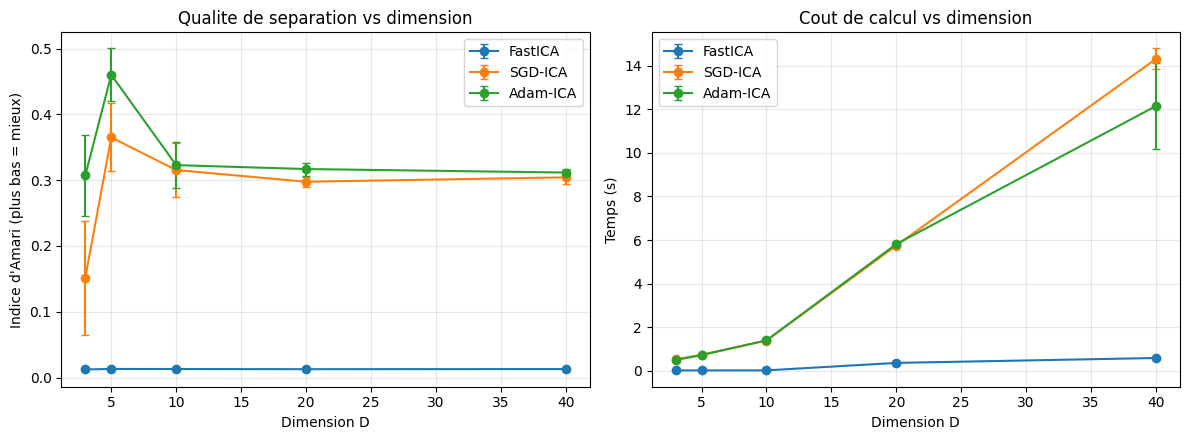

In [ ]:
import time

# Etude des ecarts selon la dimension
D_values = [3, 5, 10, 20, 40]
N = 5000
seeds = [0, 1, 2]

# Budget de calcul comparable pour les methodes stochastiques
n_iter_stochastic = 1000
batch_size = 64

rows = []

for D_cur in D_values:
    source_types_cur = ['laplace'] * D_cur
    for sd in seeds:
        X_cur, S_cur, A_cur = generate_synthetic_data(
            D=D_cur,
            N=N,
            source_types=source_types_cur,
            seed=sd,
        )
        Xw_cur, mu_cur, W_white_cur = center_whiten(X_cur)

        # FastICA via fonction du projet
        t0 = time.perf_counter()
        V_fast_cur, _, _, _, _ = fastica_unmixing_matrix(
            X_cur,
            whitening_fn=center_whiten,
            n_components=D_cur,
            max_iter=1000,
            tol=1e-6,
            seed=sd,
        )
        t_fast = time.perf_counter() - t0
        C_fast = V_fast_cur @ A_cur
        amari_fast = amari_index(C_fast)

        rows.append({
            'D': D_cur,
            'seed': sd,
            'algo': 'FastICA',
            'amari': amari_fast,
            'time_s': t_fast,
        })

        # SGD-ICA
        t0 = time.perf_counter()
        W_sgd_cur, _ = sgd_ica(
            Xw_cur,
            n_iter=n_iter_stochastic,
            lr=0.01,
            batch_size=batch_size,
            seed=sd,
        )
        t_sgd = time.perf_counter() - t0
        C_sgd_cur = (W_sgd_cur @ W_white_cur) @ A_cur
        amari_sgd_cur = amari_index(C_sgd_cur)

        rows.append({
            'D': D_cur,
            'seed': sd,
            'algo': 'SGD-ICA',
            'amari': amari_sgd_cur,
            'time_s': t_sgd,
        })

        # Adam-ICA
        t0 = time.perf_counter()
        W_adam_cur, _ = adam_ica(
            Xw_cur,
            n_iter=n_iter_stochastic,
            lr=0.0005,
            batch_size=batch_size,
            seed=sd,
        )
        t_adam = time.perf_counter() - t0
        C_adam_cur = (W_adam_cur @ W_white_cur) @ A_cur
        amari_adam_cur = amari_index(C_adam_cur)

        rows.append({
            'D': D_cur,
            'seed': sd,
            'algo': 'Adam-ICA',
            'amari': amari_adam_cur,
            'time_s': t_adam,
        })

# Agregation simple sans pandas
algos = ['FastICA', 'SGD-ICA', 'Adam-ICA']
summary = {a: {'D': [], 'amari_mean': [], 'amari_std': [], 'time_mean': [], 'time_std': []} for a in algos}

for D_cur in D_values:
    for a in algos:
        vals_a = [r['amari'] for r in rows if r['D'] == D_cur and r['algo'] == a]
        vals_t = [r['time_s'] for r in rows if r['D'] == D_cur and r['algo'] == a]
        summary[a]['D'].append(D_cur)
        summary[a]['amari_mean'].append(float(np.mean(vals_a)))
        summary[a]['amari_std'].append(float(np.std(vals_a)))
        summary[a]['time_mean'].append(float(np.mean(vals_t)))
        summary[a]['time_std'].append(float(np.std(vals_t)))

# Affichage tabulaire compact
print('=== Moyennes par dimension (sur seeds) ===')
for D_cur in D_values:
    print(f'\nD = {D_cur}')
    for a in algos:
        i = summary[a]['D'].index(D_cur)
        am = summary[a]['amari_mean'][i]
        ams = summary[a]['amari_std'][i]
        tm = summary[a]['time_mean'][i]
        tms = summary[a]['time_std'][i]
        print(f'  {a:8s} | Amari={am:.4f} +/- {ams:.4f} | Time={tm:.3f}s +/- {tms:.3f}s')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for a in algos:
    axes[0].errorbar(
        summary[a]['D'],
        summary[a]['amari_mean'],
        yerr=summary[a]['amari_std'],
        marker='o',
        capsize=3,
        label=a,
    )
axes[0].set_xlabel('Dimension D')
axes[0].set_ylabel('Indice d\'Amari (plus bas = mieux)')
axes[0].set_title('Qualite de separation vs dimension')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for a in algos:
    axes[1].errorbar(
        summary[a]['D'],
        summary[a]['time_mean'],
        yerr=summary[a]['time_std'],
        marker='o',
        capsize=3,
        label=a,
    )
axes[1].set_xlabel('Dimension D')
axes[1].set_ylabel('Temps (s)')
axes[1].set_title('Cout de calcul vs dimension')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

=== Scalabilite en N (D=20, epochs stochastiques=5) ===

N = 1000
  FastICA  | Amari=0.0289 +/- 0.0024 | Time=0.067s +/- 0.070s
  SGD-ICA  | Amari=0.3451 +/- 0.0207 | Time=0.085s +/- 0.026s
  Adam-ICA | Amari=0.3474 +/- 0.0193 | Time=0.067s +/- 0.015s

N = 2000
  FastICA  | Amari=0.0207 +/- 0.0004 | Time=0.133s +/- 0.031s
  SGD-ICA  | Amari=0.3413 +/- 0.0096 | Time=0.212s +/- 0.013s
  Adam-ICA | Amari=0.3485 +/- 0.0123 | Time=0.186s +/- 0.001s

N = 5000
  FastICA  | Amari=0.0127 +/- 0.0003 | Time=0.275s +/- 0.019s
  SGD-ICA  | Amari=0.3251 +/- 0.0054 | Time=2.250s +/- 0.027s
  Adam-ICA | Amari=0.3234 +/- 0.0133 | Time=2.075s +/- 0.281s

N = 10000
  FastICA  | Amari=0.0089 +/- 0.0003 | Time=0.470s +/- 0.010s
  SGD-ICA  | Amari=0.3206 +/- 0.0108 | Time=9.542s +/- 0.716s
  Adam-ICA | Amari=0.3294 +/- 0.0224 | Time=8.646s +/- 1.456s


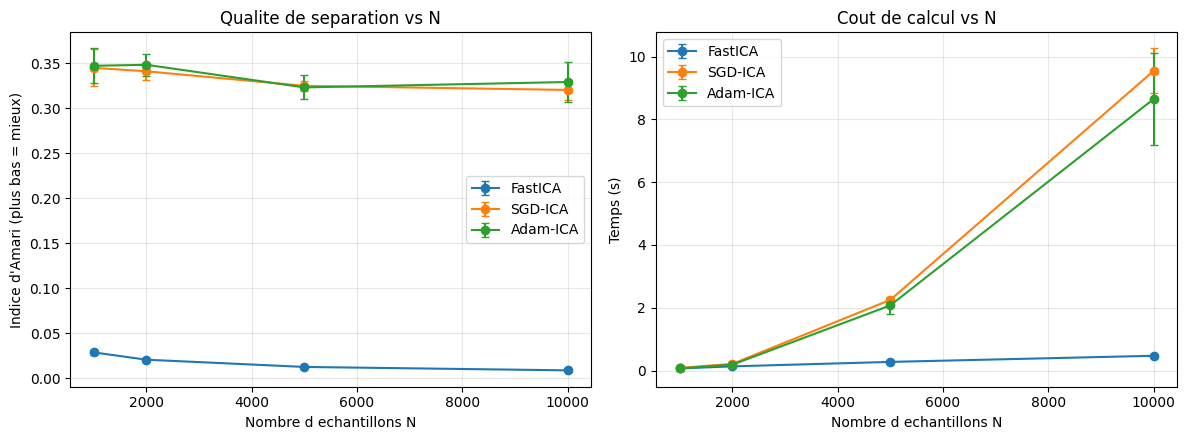

In [ ]:
import math
import time

D_fix = 20
N_values = [1000, 2000, 5000, 10000]
seeds = [0, 1, 2]
source_types_fix = ['laplace'] * D_fix

batch_size = 64
epochs_stochastic = 5

rows_N = []

for N_cur in N_values:
    n_iter_cur = math.ceil(epochs_stochastic * N_cur / batch_size)
    for sd in seeds:
        X_cur, S_cur, A_cur = generate_synthetic_data(
            D=D_fix,
            N=N_cur,
            source_types=source_types_fix,
            seed=sd,
        )
        Xw_cur, mu_cur, W_white_cur = center_whiten(X_cur)

        # FastICA via fonction du projet
        t0 = time.perf_counter()
        V_fast_cur, _, _, _, _ = fastica_unmixing_matrix(
            X_cur,
            whitening_fn=center_whiten,
            n_components=D_fix,
            max_iter=1000,
            tol=1e-6,
            seed=sd,
        )
        t_fast = time.perf_counter() - t0
        C_fast = V_fast_cur @ A_cur
        rows_N.append({'N': N_cur, 'seed': sd, 'algo': 'FastICA', 'amari': amari_index(C_fast), 'time_s': t_fast})

        # SGD-ICA
        t0 = time.perf_counter()
        W_sgd_cur, _ = sgd_ica(Xw_cur, n_iter=n_iter_cur, lr=0.01, batch_size=batch_size, seed=sd)
        t_sgd = time.perf_counter() - t0
        C_sgd_cur = (W_sgd_cur @ W_white_cur) @ A_cur
        rows_N.append({'N': N_cur, 'seed': sd, 'algo': 'SGD-ICA', 'amari': amari_index(C_sgd_cur), 'time_s': t_sgd})

        # Adam-ICA
        t0 = time.perf_counter()
        W_adam_cur, _ = adam_ica(Xw_cur, n_iter=n_iter_cur, lr=0.001, batch_size=batch_size, seed=sd)
        t_adam = time.perf_counter() - t0
        C_adam_cur = (W_adam_cur @ W_white_cur) @ A_cur
        rows_N.append({'N': N_cur, 'seed': sd, 'algo': 'Adam-ICA', 'amari': amari_index(C_adam_cur), 'time_s': t_adam})

algos = ['FastICA', 'SGD-ICA', 'Adam-ICA']
summary_N = {a: {'N': [], 'amari_mean': [], 'amari_std': [], 'time_mean': [], 'time_std': []} for a in algos}

for N_cur in N_values:
    for a in algos:
        vals_a = [r['amari'] for r in rows_N if r['N'] == N_cur and r['algo'] == a]
        vals_t = [r['time_s'] for r in rows_N if r['N'] == N_cur and r['algo'] == a]
        summary_N[a]['N'].append(N_cur)
        summary_N[a]['amari_mean'].append(float(np.mean(vals_a)))
        summary_N[a]['amari_std'].append(float(np.std(vals_a)))
        summary_N[a]['time_mean'].append(float(np.mean(vals_t)))
        summary_N[a]['time_std'].append(float(np.std(vals_t)))

print(f'=== Scalabilite en N (D={D_fix}, epochs stochastiques={epochs_stochastic}) ===')
for N_cur in N_values:
    print(f'\nN = {N_cur}')
    for a in algos:
        i = summary_N[a]['N'].index(N_cur)
        am = summary_N[a]['amari_mean'][i]
        ams = summary_N[a]['amari_std'][i]
        tm = summary_N[a]['time_mean'][i]
        tms = summary_N[a]['time_std'][i]
        print(f'  {a:8s} | Amari={am:.4f} +/- {ams:.4f} | Time={tm:.3f}s +/- {tms:.3f}s')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for a in algos:
    axes[0].errorbar(summary_N[a]['N'], summary_N[a]['amari_mean'], yerr=summary_N[a]['amari_std'], marker='o', capsize=3, label=a)
axes[0].set_xlabel('Nombre d echantillons N')
axes[0].set_ylabel('Indice d\'Amari (plus bas = mieux)')
axes[0].set_title('Qualite de separation vs N')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for a in algos:
    axes[1].errorbar(summary_N[a]['N'], summary_N[a]['time_mean'], yerr=summary_N[a]['time_std'], marker='o', capsize=3, label=a)
axes[1].set_xlabel('Nombre d echantillons N')
axes[1].set_ylabel('Temps (s)')
axes[1].set_title('Cout de calcul vs N')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Scalabilite en N (nombre d'echantillons)

On fixe la dimension D et on augmente N.
Pour les methodes stochastiques, on garde un nombre d'epochs fixe afin de comparer a budget d'apprentissage comparable.

Mesures:
- Qualite: indice d'Amari (plus bas = mieux)
- Cout: temps d'execution (secondes)